Description - Toy data set generated by sampling 20 inputs x
uniformly at random in the interval [−4, 4]. For each
value of x obtained, the corresponding target y is computed as y = x
3 + n, where n ∼ N (0, 9). We fitted a
neural network with one layer and 100 hidden units

In [157]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

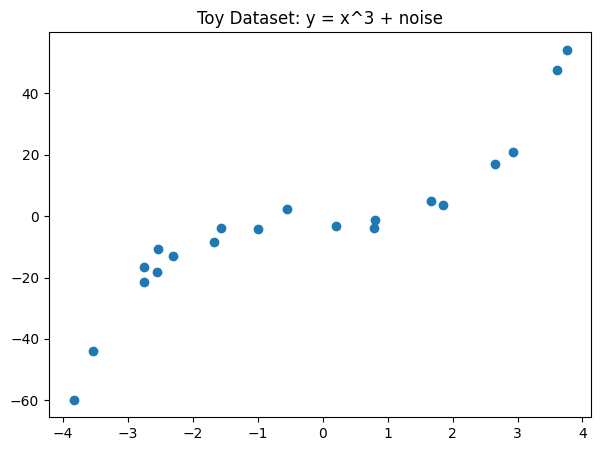

In [158]:
torch.manual_seed(42)
np.random.seed(42)
N = 20

x = np.random.uniform(-4, 4, N)
noise = np.random.normal(0, 3, N)

y = x**3 + noise

X = torch.tensor(x,dtype=torch.float32).unsqueeze(1)
Y = torch.tensor(y,dtype=torch.float32).unsqueeze(1)

x_test = np.linspace(-6,6,400)
X_test = torch.tensor(x_test,dtype=torch.float32).unsqueeze(1)

plt.figure(figsize=(7,5))
plt.scatter(x, y)
plt.title("Toy Dataset: y = x^3 + noise")
plt.show()

In [159]:
class MSENet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,50),
            nn.ReLU(),
            nn.Linear(50,1)
        )

    def forward(self,x):
        return self.net(x)


In [160]:
num_models = 15
num_epochs = 10000
lr = 0.1
mse_models = []

for n in range(num_models):
    m = MSENet()
    opt = optim.Adam(m.parameters(),lr=lr)
    for ep in range(num_epochs):
        opt.zero_grad()
        loss = nn.MSELoss()(m(X),Y)
        loss.backward()
        opt.step()
    mse_models.append(m)

predictions = np.array([m(X_test).detach().numpy() for m in mse_models]).squeeze()
mse_mean = predictions.mean(0)
mse_std = predictions.std(0)

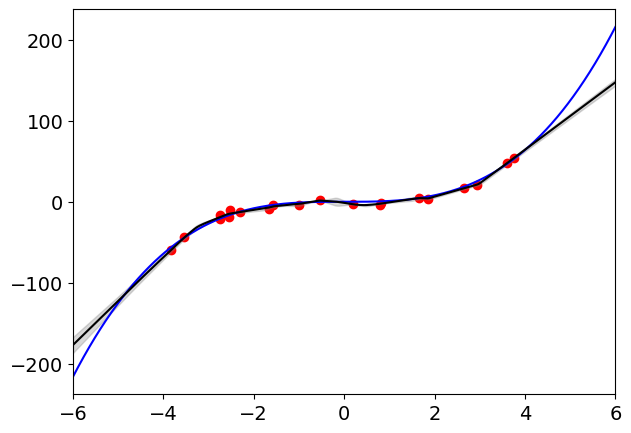

In [161]:
plt.figure(figsize=(7,5))
plt.scatter(x,y,color="red")
plt.plot(x_test,x_test**3,color="blue")
plt.plot(x_test,mse_mean,color="black")
plt.fill_between(x_test,mse_mean-3*mse_std,mse_mean+3*mse_std, color="gray",alpha=0.3)
plt.xlim(-6,6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [162]:
import torch.nn.functional as F
class NLLNet(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1,50),
            nn.ReLU(),
        )

        self.mean_head = nn.Linear(50,1)
        self.var_head = nn.Linear(50,1)

    def forward(self,x):
        x = self.net(x)
        x_mean = self.mean_head(x)
        x_var = self.var_head(x)
        x_var = F.softplus(x_var) + 1e-6
        return x_mean, x_var


In [163]:
def nll_criterion_regression(predictions, targets):
    means, variances = predictions
    return torch.mean( torch.log(variances)/2 + (targets - means)**2 / (2 * variances) ) 

In [164]:
num_model = 1
num_epochs = 10000
lr = 0.1

m = NLLNet()
opt = optim.Adam(m.parameters(),lr=lr)
for ep in range(num_epochs):
    opt.zero_grad()
    mean, var = m(X)
    loss = nll_criterion_regression((mean, var), Y)
    loss.backward()
    opt.step()
nll_model = m

predictions = nll_model(X_test)
nll_mean, nll_std = predictions[0].detach().numpy().squeeze(), predictions[1].sqrt().detach().numpy().squeeze()

In [165]:
print(nll_mean.shape)
print(nll_std.shape)

(400,)
(400,)


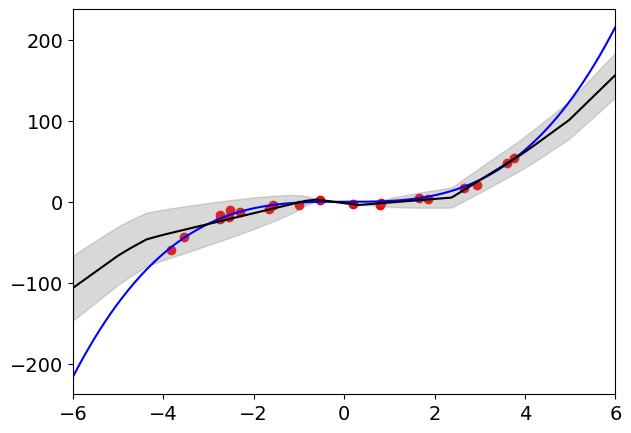

In [166]:
plt.figure(figsize=(7,5))
plt.scatter(x,y,color="red")
plt.plot(x_test,x_test**3,color="blue")
plt.plot(x_test,nll_mean,color="black")
plt.fill_between(x_test,nll_mean-3*nll_std,nll_mean+3*nll_std, color="gray",alpha=0.3)
plt.xlim(-6,6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()

In [ ]:
num_models = 15
num_epochs = 10000
lr = 0.1
nll_models = []

for n in range(num_models):
    m = NLLNet()
    opt = optim.Adam(m.parameters(),lr=lr)
    for ep in range(num_epochs):
        opt.zero_grad()
        mean, var = m(X)
        loss = nll_criterion_regression((mean, var), Y)
        loss.backward()
        opt.step()
    nll_models.append(m)

predictions = [m(X_test) for m in nll_models]
nll_means = np.array([pred[0].detach().numpy().squeeze() for pred in predictions])
nll_vars = np.array([pred[1].detach().numpy().squeeze() for pred in predictions])
nll_mean = nll_means.mean(0)
nll_std = nll_means.std(0)

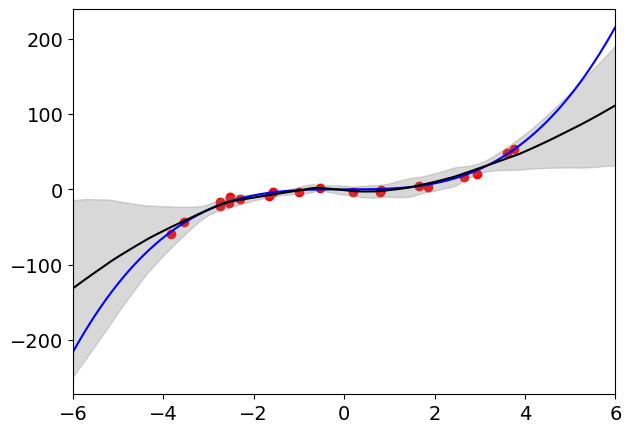

In [168]:
plt.figure(figsize=(7,5))
plt.scatter(x,y,color="red")
plt.plot(x_test,x_test**3,color="blue")
plt.plot(x_test,nll_mean,color="black")
plt.fill_between(x_test,nll_mean-3*nll_std,nll_mean+3*nll_std, color="gray",alpha=0.3)
plt.xlim(-6,6)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.show()